# Round 0 Market Data Analysis

This notebook loads the 4 round-0 CSV files:

- `prices_round_0_day_-1.csv`
- `prices_round_0_day_-2.csv`
- `trades_round_0_day_-1.csv`
- `trades_round_0_day_-2.csv`

and then:

1. combines the two price files
2. combines the two trade files
3. merges trades with the nearest earlier order book snapshot
4. infers likely trade direction
5. computes summary statistics
6. draws a few useful plots for strategy research


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Set file paths

Update these paths if your files are stored somewhere else.


In [7]:
PRICES_D1 = "data/prices_round_0_day_-1.csv"
PRICES_D2 = "data/prices_round_0_day_-2.csv"
TRADES_D1 = "data/trades_round_0_day_-1.csv"
TRADES_D2 = "data/trades_round_0_day_-2.csv"

## Load and combine the two price files

In [8]:
prices_d1 = pd.read_csv(PRICES_D1, sep=";")
prices_d2 = pd.read_csv(PRICES_D2, sep=";")

prices = pd.concat([prices_d1, prices_d2], ignore_index=True)

# Standardize product column name
if "product" in prices.columns:
    prices = prices.rename(columns={"product": "symbol"})

prices = prices.sort_values(["day", "symbol", "timestamp"]).reset_index(
    drop=True
)

print("Prices shape:", prices.shape)
prices.head()

Prices shape: (40000, 17)


,day,timestamp,symbol,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
2,-2,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
3,-2,300,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0,0.0
4,-2,400,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


## Load and combine the two trade files

In [9]:
trades_d1 = pd.read_csv(TRADES_D1, sep=";")
trades_d2 = pd.read_csv(TRADES_D2, sep=";")

# The trade files do not include day, so add it manually
trades_d1["day"] = -1
trades_d2["day"] = -2

trades = pd.concat([trades_d1, trades_d2], ignore_index=True)
trades = trades.sort_values(["day", "symbol", "timestamp"]).reset_index(
    drop=True
)

print("Trades shape:", trades.shape)
trades.head()

Trades shape: (1219, 8)


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2
1,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2
2,10500,NaN,NaN,EMERALDS,XIRECS,10008.0,5,-2
3,11300,NaN,NaN,EMERALDS,XIRECS,9992.0,3,-2
4,22800,NaN,NaN,EMERALDS,XIRECS,10000.0,6,-2


## Basic feature engineering on the price data

In [10]:
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]

if "mid_price" not in prices.columns:
    prices["mid_price"] = (prices["bid_price_1"] + prices["ask_price_1"]) / 2

prices["mid_return"] = prices.groupby(["day", "symbol"])["mid_price"].diff()

prices[
    [
        "day",
        "symbol",
        "timestamp",
        "bid_price_1",
        "ask_price_1",
        "mid_price",
        "spread",
    ]
].head()

,day,symbol,timestamp,bid_price_1,ask_price_1,mid_price,spread
0,-2,EMERALDS,0,9992,10008,10000.0,16
1,-2,EMERALDS,100,9992,10008,10000.0,16
2,-2,EMERALDS,200,9992,10008,10000.0,16
3,-2,EMERALDS,300,9992,10008,10000.0,16
4,-2,EMERALDS,400,9992,10008,10000.0,16


## Merge trades with the nearest earlier order book snapshot

Using `direction="backward"` means each trade is matched with the most recent earlier book snapshot for the same day and symbol.


In [12]:
trades_for_merge = trades.sort_values(
    ["timestamp", "day", "symbol"]
).reset_index(drop=True)

prices_for_merge = prices.sort_values(
    ["timestamp", "day", "symbol"]
).reset_index(drop=True)

merged = pd.merge_asof(
    trades_for_merge,
    prices_for_merge,
    on="timestamp",
    by=["day", "symbol"],
    direction="backward",
)

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (1219, 24)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,mid_return
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2,4994,5,4993,24,NaN,NaN,5008,5,5009,24,NaN,NaN,5001.0,0.0,14,1.0
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2,4993,5,4992,18,NaN,NaN,5006,5,5008,18,NaN,NaN,4999.5,0.0,13,0.5
2,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8,-1,9992,12,9990,22,NaN,NaN,10008,12,10010,22,NaN,NaN,10000.0,0.0,16,0.0
3,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2,-1,4996,10,4994,17,NaN,NaN,5009,10,5011,17,NaN,NaN,5002.5,0.0,13,-0.5
4,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2,9992,10,9990,27,NaN,NaN,10008,10,10010,27,NaN,NaN,10000.0,0.0,16,0.0


## Infer likely trade direction

In [24]:
def classify_trade(row):
    bid = row["bid_price_1"]
    ask = row["ask_price_1"]
    p = row["price"]
    mid = row["mid_price"]

    if pd.isna(bid) or pd.isna(ask):
        return "unknown"
    if p == ask:
        return "buy_initiated"
    if p == bid:
        return "sell_initiated"
    if p > mid:
        return "lean_buy"
    if p < mid:
        return "lean_sell"
    return "unknown"


merged["trade_side"] = merged.apply(classify_trade, axis=1)
merged["trade_minus_mid"] = merged["price"] - merged["mid_price"]

merged[
    [
        "day",
        "timestamp",
        "symbol",
        "price",
        "quantity",
        "bid_price_1",
        "ask_price_1",
        "mid_price",
        "trade_side",
        "trade_minus_mid",
    ]
].sort_values(["day", "timestamp"]).to_csv("data/order_book.csv")

## Summary statistics

In [14]:
print("Average spread by symbol")
display(
    prices.groupby("symbol")["spread"].agg(
        ["mean", "median", "std", "min", "max"]
    )
)

print("\nTrade count by symbol")
display(trades.groupby("symbol").size().rename("n_trades").to_frame())

print("\nTotal traded quantity by symbol")
display(
    trades.groupby("symbol")["quantity"]
    .sum()
    .rename("total_quantity")
    .to_frame()
)

print("\nTrade-side counts by symbol")
display(
    merged.groupby(["symbol", "trade_side"]).size().rename("count").to_frame()
)

print("\nAverage trade minus mid by symbol")
display(
    merged.groupby("symbol")["trade_minus_mid"].agg(["mean", "median", "std"])
)

Average spread by symbol


,mean,median,std,min,max
symbol,,,,,
EMERALDS,15.73840,16.0,1.422838,8,16
TOMATOES,13.02025,13.0,1.754592,5,14



Trade count by symbol


,n_trades
symbol,
EMERALDS,399
TOMATOES,820



Total traded quantity by symbol


,total_quantity
symbol,
EMERALDS,2189
TOMATOES,2853



Trade-side counts by symbol


count
symbol   trade_side           
EMERALDS buy_initiated     195
         sell_initiated    204
TOMATOES buy_initiated     387
         sell_initiated    433


Average trade minus mid by symbol


,mean,median,std
symbol,,,
EMERALDS,-0.180451,-4.0,7.855959
TOMATOES,-0.323171,-3.5,6.533034


## Plot 1: midprice over time

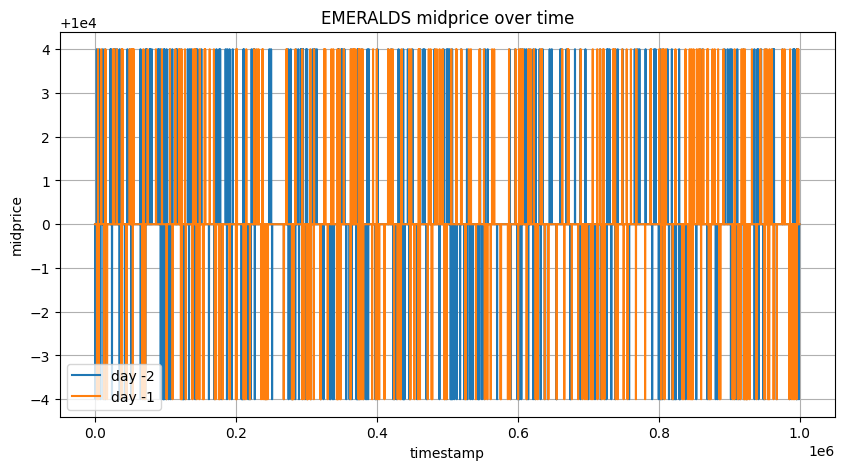

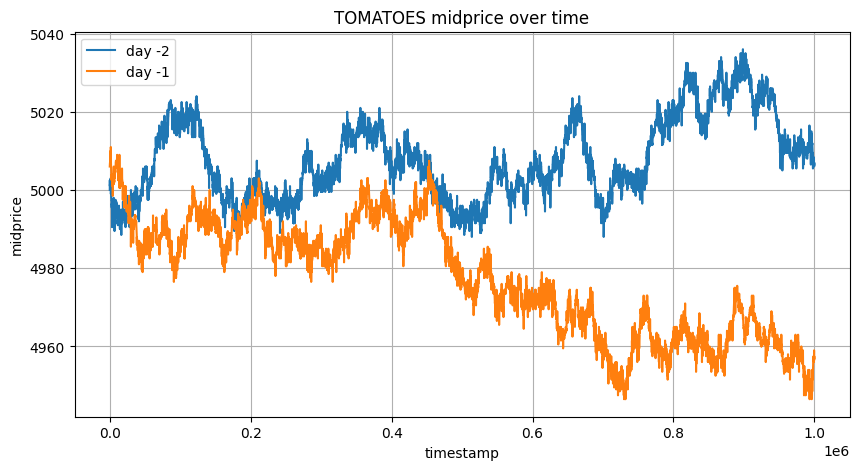

In [15]:
for symbol in sorted(prices["symbol"].unique()):
    sub = prices[prices["symbol"] == symbol].copy()
    plt.figure()
    for day in sorted(sub["day"].unique()):
        d = sub[sub["day"] == day]
        plt.plot(d["timestamp"], d["mid_price"], label=f"day {day}")
    plt.title(f"{symbol} midprice over time")
    plt.xlabel("timestamp")
    plt.ylabel("midprice")
    plt.legend()
    plt.grid(True)
    plt.show()

## Plot 2: spread over time

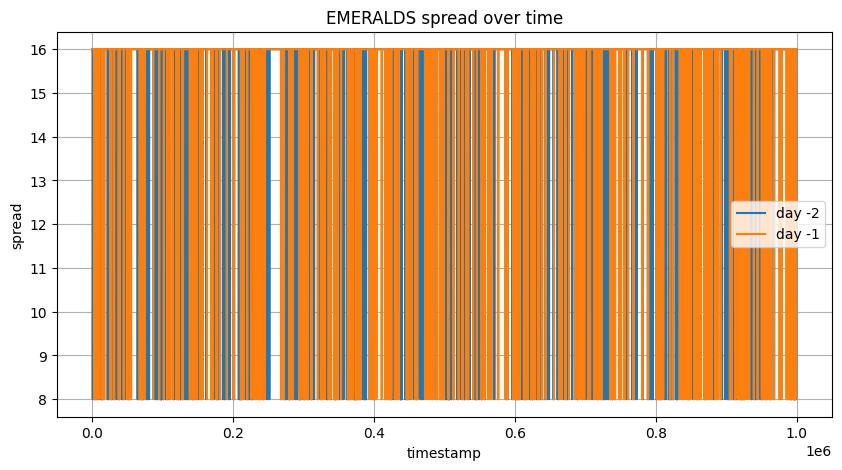

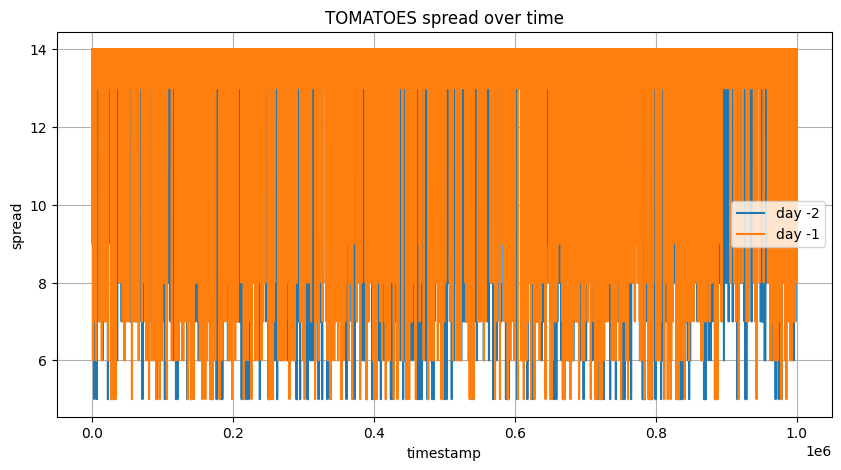

In [16]:
for symbol in sorted(prices["symbol"].unique()):
    sub = prices[prices["symbol"] == symbol].copy()
    plt.figure()
    for day in sorted(sub["day"].unique()):
        d = sub[sub["day"] == day]
        plt.plot(d["timestamp"], d["spread"], label=f"day {day}")
    plt.title(f"{symbol} spread over time")
    plt.xlabel("timestamp")
    plt.ylabel("spread")
    plt.legend()
    plt.grid(True)
    plt.show()

## Plot 3: trade prices overlaid on midprice

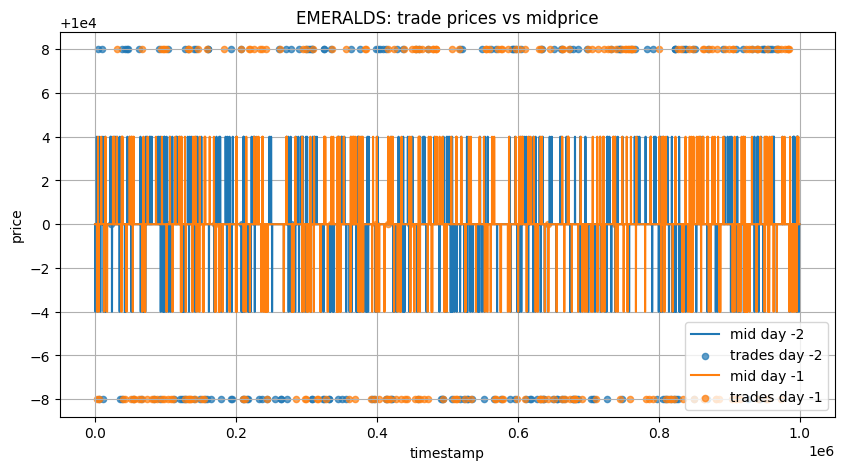

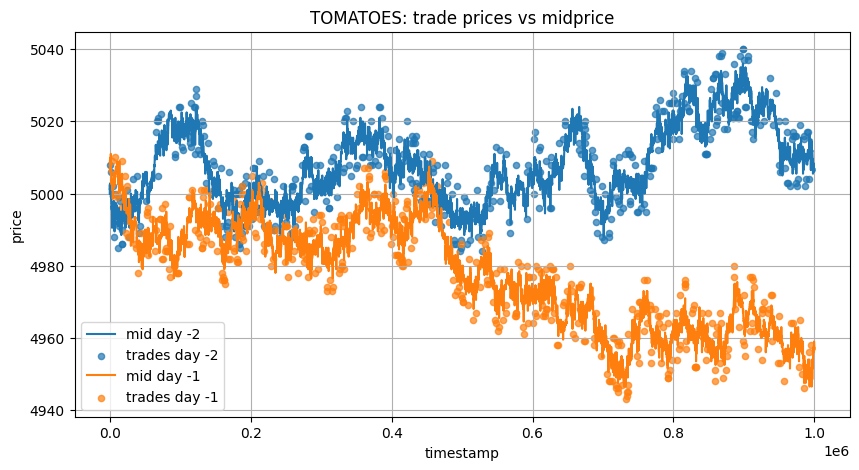

In [17]:
for symbol in sorted(prices["symbol"].unique()):
    plt.figure()
    for day in sorted(prices["day"].unique()):
        p = prices[(prices["symbol"] == symbol) & (prices["day"] == day)]
        t = trades[(trades["symbol"] == symbol) & (trades["day"] == day)]
        plt.plot(p["timestamp"], p["mid_price"], label=f"mid day {day}")
        plt.scatter(
            t["timestamp"],
            t["price"],
            s=20,
            alpha=0.7,
            label=f"trades day {day}",
        )
    plt.title(f"{symbol}: trade prices vs midprice")
    plt.xlabel("timestamp")
    plt.ylabel("price")
    plt.legend()
    plt.grid(True)
    plt.show()

## Plot 4: signed trade counts

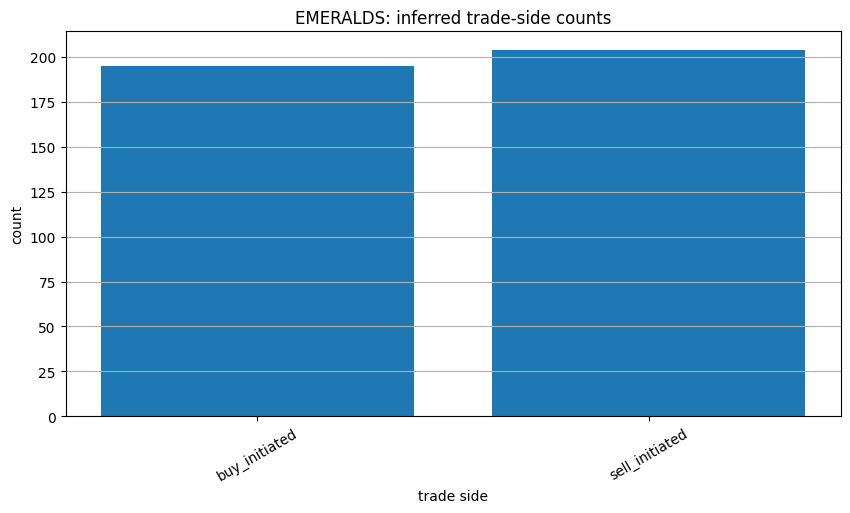

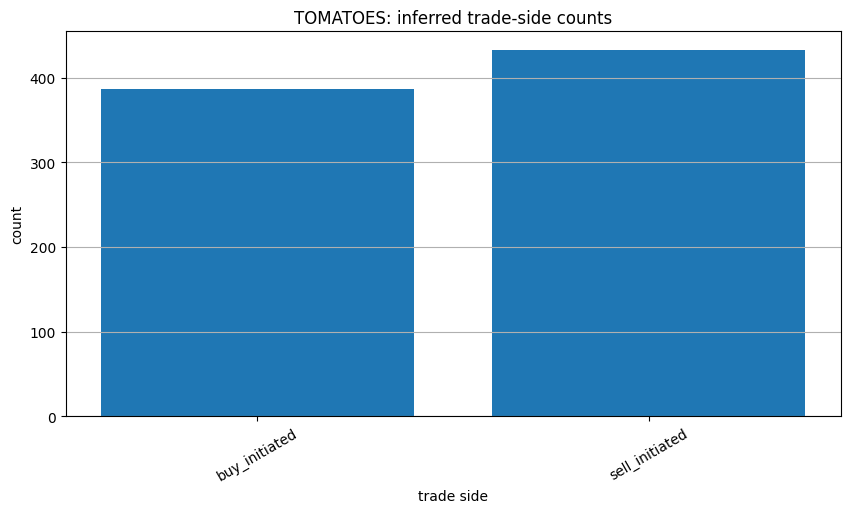

In [18]:
side_counts = (
    merged.groupby(["symbol", "trade_side"])
    .size()
    .rename("count")
    .reset_index()
)

for symbol in sorted(side_counts["symbol"].unique()):
    sub = side_counts[side_counts["symbol"] == symbol]
    plt.figure()
    plt.bar(sub["trade_side"], sub["count"])
    plt.title(f"{symbol}: inferred trade-side counts")
    plt.xlabel("trade side")
    plt.ylabel("count")
    plt.xticks(rotation=30)
    plt.grid(True, axis="y")
    plt.show()

## Optional: do trades predict short-term future midprice moves?

This checks whether the next midprice move differs by inferred trade side.


In [19]:
future_moves = prices[["day", "symbol", "timestamp", "mid_price"]].copy()
future_moves["future_mid"] = future_moves.groupby(["day", "symbol"])[
    "mid_price"
].shift(-1)
future_moves["future_move"] = (
    future_moves["future_mid"] - future_moves["mid_price"]
)

merged_future = pd.merge_asof(
    trades.sort_values(["day", "symbol", "timestamp"]).reset_index(drop=True),
    future_moves.sort_values(["day", "symbol", "timestamp"]).reset_index(
        drop=True
    ),
    on="timestamp",
    by=["day", "symbol"],
    direction="backward",
)

merged_future = pd.merge(
    merged_future,
    merged[["day", "symbol", "timestamp", "trade_side"]],
    on=["day", "symbol", "timestamp"],
    how="left",
)

display(
    merged_future.groupby(["symbol", "trade_side"])["future_move"]
    .agg(["mean", "median", "count"])
    .sort_index()
)

ValueError: left keys must be sorted

## Notes for strategy design

Useful things to look for:

- Is **EMERALDS** close to a fixed fair value?
- Is **TOMATOES** more volatile or directional?
- Do trades tend to happen at bid or ask?
- Do buy-initiated trades predict future upward moves?
- Is the spread wide enough for passive market making?
